In [43]:
import os
import glob
import pandas as pd
import whisper
from jiwer import wer, cer, Compose, ToLowerCase, RemovePunctuation, Strip, RemoveMultipleSpaces
from pathlib import Path
import matplotlib.pyplot as plt

DATA_ROOT = os.path.join("data", "ami")

AUDIO_DIR = os.path.join(DATA_ROOT, "audio")
SUMMARY_DIR = os.path.join(DATA_ROOT, "summary")
TRANSCRIPT_DIR = os.path.join(DATA_ROOT, "transcript")

In [44]:
def parse_transcript(filepath):

    utterances = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            parts = line.strip().split("\t")

            if len(parts) != 4:
                print('Transcript line parts mismatch')
                continue

            speaker, start_time, text, section = parts

            utterances.append({
                "speaker": speaker,
                "start_time": float(start_time),
                "text": text,
                "section": section
            })

    utterance_df = pd.DataFrame(utterances)

    if len(utterance_df) == 0:
        return "", utterance_df

    # Build full transcript text
    transcript_text = " ".join(utterance_df["text"].tolist())

    return transcript_text, utterance_df

In [45]:
def load_transcripts(transcript_dir):

    records = []

    for split in ["train", "valid", "test"]:

        split_dir = os.path.join(transcript_dir, split)

        for filepath in glob.glob(os.path.join(split_dir, "*.txt")):

            meeting_id = os.path.basename(filepath).replace(".txt", "")

            transcript_text, utterance_df = parse_transcript(filepath)

            records.append({
                "meeting_id": meeting_id,
                "split": split,
                "transcript": transcript_text,
                "num_utterances": len(utterance_df),
                "num_speakers": utterance_df["speaker"].nunique()
            })

    return pd.DataFrame(records)

In [46]:
def load_summaries(summary_dir):

    summaries = {}

    for filepath in glob.glob(os.path.join(summary_dir, "*.txt")):
        meeting_id = os.path.basename(filepath).replace(".txt", "")

        with open(filepath, "r", encoding="utf-8") as f:
            summaries[meeting_id] = f.read()

    return summaries

In [47]:
def load_audio_paths(audio_dir):

    audio_records = []

    for meeting in os.listdir(audio_dir):

        meeting_audio_dir = os.path.join(audio_dir, meeting, "audio")

        if not os.path.isdir(meeting_audio_dir):
            continue

        headset = None
        lapel = None

        for file in os.listdir(meeting_audio_dir):

            if "Headset" in file:
                headset = os.path.join(meeting_audio_dir, file)

            if "Lapel" in file:
                lapel = os.path.join(meeting_audio_dir, file)

        audio_records.append({
            "meeting_id": meeting,
            "audio_headset": headset,
            "audio_lapel": lapel
        })

    return pd.DataFrame(audio_records)

In [48]:
def build_dataset():
    transcripts_df = load_transcripts(TRANSCRIPT_DIR)

    summaries = load_summaries(SUMMARY_DIR)

    audio_df = load_audio_paths(AUDIO_DIR)

    # attach summaries
    transcripts_df["summary"] = transcripts_df["meeting_id"].map(summaries)

    # merge audio paths
    df = transcripts_df.merge(audio_df, on="meeting_id", how="left")
    
    # get the transcript and summary lengths in tokens, and the ratio of summary length to transcript length
    # we also tested character counts, but the ratios were very similar to token counts
    df['transcript_length'] = df['transcript'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['summary_length'] = df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['ratio_summary_to_transcript'] = df.apply(lambda row: row['summary_length'] / row['transcript_length'] if row['transcript_length'] > 0 else 0, axis=1)

    return df

Weighted WER:  0.349
Weighted CER:  0.263


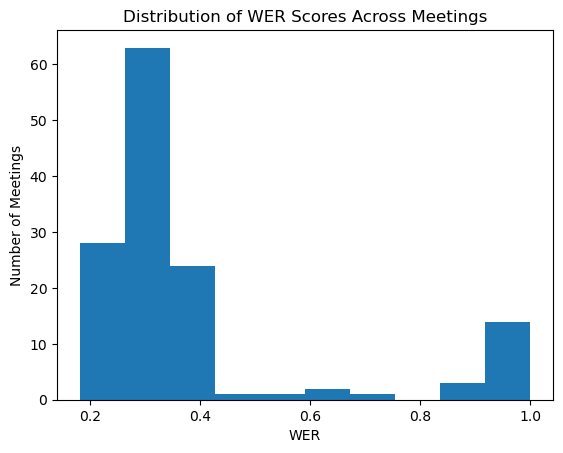

Text(0.5, 1.0, 'WER vs CER Scatterplot')

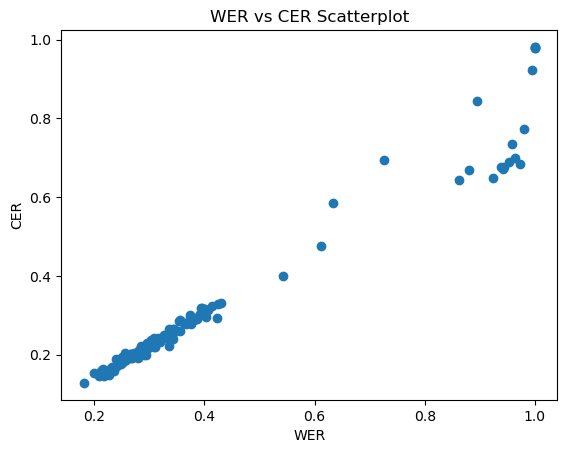

In [ ]:
df = build_dataset()

#print(df.shape)
#print(df.head())

# Load base model for Whisper
#model = whisper.load_model("base")

# Load audio paths for meetings
#audio = df["audio_headset"]
p = r"C:\Users\culle\Downloads\AI-574-Group4-Main"
#for a in audio:
#    file_path = os.path.join(p, a)
    # Transcribe the found audio file
#    result = model.transcribe(file_path)

    # Set the output path and name for the transcribition so it can be accessed later
#    a_path = os.path.splitext(os.path.basename(file_path))[0]
#    output_path = os.path.join(p + "\Text\Tran" + a_path + ".txt")
#    with open(output_path, "w", encoding = "utf-8") as f:
#        f.write(result["text"])

# Set the two paths for both the whisper and ami transcripts
whisper_path = os.path.join(p + "\Text")
transcript_path = r"C:\Users\culle\Downloads\AI-574-Group4-Main\Transcripts"

# Used to normalize the text in the transcripts
transform = Compose([ToLowerCase(), RemovePunctuation(), Strip(), RemoveMultipleSpaces()])

def remove_fillers(text):
    # Used to remove filler words
    fillers = {"uh", "um", "uhh", "umm", "hmm", "ah", "oh", "er", "mm", "mhm"}
    words = text.split()
    words = [w for w in words if w not in fillers]

    return " ".join(words)

results = []

# Go through all whisper transcripts
for f in os.listdir(whisper_path):
    if f.endswith(".txt"):
        # Get the path for each transcript file
        w_path = os.path.join(whisper_path, f)
        t_path = os.path.join(transcript_path, f)

        # Load in the text from both transcripts
        whis = ""
        trans = ""
        with open(w_path, "r", encoding = "utf-8") as f:
            whis = f.read()

        with open(t_path, "r", encoding = "utf-8") as f:
            tran = f.read()

        # Normalize text
        normal_whis = transform(whis)
        normal_tran = transform(tran)

        # Remove filler words
        normal_whis = remove_fillers(normal_whis)
        normal_tran = remove_fillers(normal_tran)

        # Get the wer and cer scores for whisper transcript using both transcripts
        whis_wer = wer(normal_tran, normal_whis)
        whis_cer = cer(normal_tran, normal_whis)

        # Add found data to results
        results.append((Path(f.name).stem, whis_wer, whis_cer))

total_words = 0
weighted_sum = 0
total_chars = 0
weighted_csum = 0

# Go through all meetings in results
for meeting_id, wer_score, cer_score in results:
    # Read the data to get the total word/char count
    ref = open(f"{whisper_path}\{meeting_id}.txt").read()
    word_count = len(ref.split())
    char_count = len(ref)

    # Use the total words to get the weighted sum and weighted average for wer
    total_words += word_count
    weighted_sum += wer_score * word_count
    weighted_avg = weighted_sum / total_words

    # Use the total chars to get the weighted sum and weighted average for cer
    total_chars += char_count
    weighted_csum += cer_score * char_count
    weighted_cavg = weighted_csum / total_chars

# Prints the average wer and cer scores
print("Weighted WER: ", round(weighted_avg, 3))
print("Weighted CER: ", round(weighted_cavg, 3))

# Get the wer and cer scores in results
wer_scores = [r[1] for r in results]
cer_scores = [r[2] for r in results]

# Plot a distribution showing the wer scores for each meeting
plt.hist(wer_scores, bins=10)
plt.xlabel("WER")
plt.ylabel("Number of Meetings")
plt.title("Distribution of WER Scores Across Meetings")
plt.show()

# Plot a scatterplot showing the wer vs cer scores for each meeting
plt.scatter(wer_scores, cer_scores)
plt.xlabel("WER")
plt.ylabel("CER")
plt.title("WER vs CER Scatterplot")
plt.show()